In [1]:
import sys
!{sys.executable} -m pip install torch torchvision numpy pandas matplotlib seaborn pillow scikit-learn

  Using cached torchvision-0.27.0-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
Using cached torchvision-0.27.0-cp310-cp310-win_amd64.whl (3.4 MB)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix

# Determine if a GPU is available, otherwise default to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"📡 System is executing on: {device}")


📡 System is executing on: cpu


In [5]:
# 1. Define image transformations
# Training needs Data Augmentation (random flips, rotations) to prevent overfitting
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010]) # standard CIFAR values
])

# Testing transformation (No augmentation, only convert to tensor and normalize)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

# 2. Download raw CIFAR-10 Dataset
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
full_test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

# 3. Filter for Binary Classification: Class 0 (Airplane) and Class 1 (Automobile)
def get_binary_indices(dataset):
    # Returns only indices where target class is 0 or 1
    return [i for i, label in enumerate(dataset.targets) if label in [0, 1]]

train_indices = get_binary_indices(full_train_dataset)
test_indices = get_binary_indices(full_test_dataset)

# Create subsets
train_subset = Subset(full_train_dataset, train_indices[:2000]) # use 2000 training images for speed
test_subset = Subset(full_test_dataset, test_indices[:400])    # use 400 test images

# 4. Create DataLoader streams
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

print(f"✅ Preprocessing Complete!")
print(f"Training images: {len(train_subset)} | Testing images: {len(test_subset)}")


100.0%


✅ Preprocessing Complete!
Training images: 2000 | Testing images: 400


In [7]:
# Load pretrained ResNet18 model
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# Freeze all pretrained convolutional feature extractor layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer (fc) with a binary output classifier
# model.fc.in_features is 512 for ResNet18. We output 2 classes (Airplane vs Automobile)
model.fc = nn.Linear(model.fc.in_features, 2)

# Move the model to your CPU or GPU
model = model.to(device)

# Define Loss function (CrossEntropy) and Optimizer (Adam)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

print("✅ Pretrained ResNet18 model imported and final layer configured for transfer learning!")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\nskum/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


✅ Pretrained ResNet18 model imported and final layer configured for transfer learning!


In [9]:
epochs = 5
train_losses = []
train_accuracies = []

print("🚀 Starting Training Loop (Running on CPU)...")
for epoch in range(epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero out the gradient buffers
        optimizer.zero_grad()
        
        # Forward pass: get predictions
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass: calculate gradients and update weights
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    epoch_loss = running_loss / len(train_subset)
    epoch_acc = (correct / total) * 100
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] -> Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

print("🎉 Model Training Complete!")


🚀 Starting Training Loop (Running on CPU)...
Epoch [1/5] -> Loss: 0.5832 | Accuracy: 69.55%
Epoch [2/5] -> Loss: 0.4489 | Accuracy: 80.55%
Epoch [3/5] -> Loss: 0.4743 | Accuracy: 77.65%
Epoch [4/5] -> Loss: 0.4570 | Accuracy: 78.50%
Epoch [5/5] -> Loss: 0.4251 | Accuracy: 79.80%
🎉 Model Training Complete!


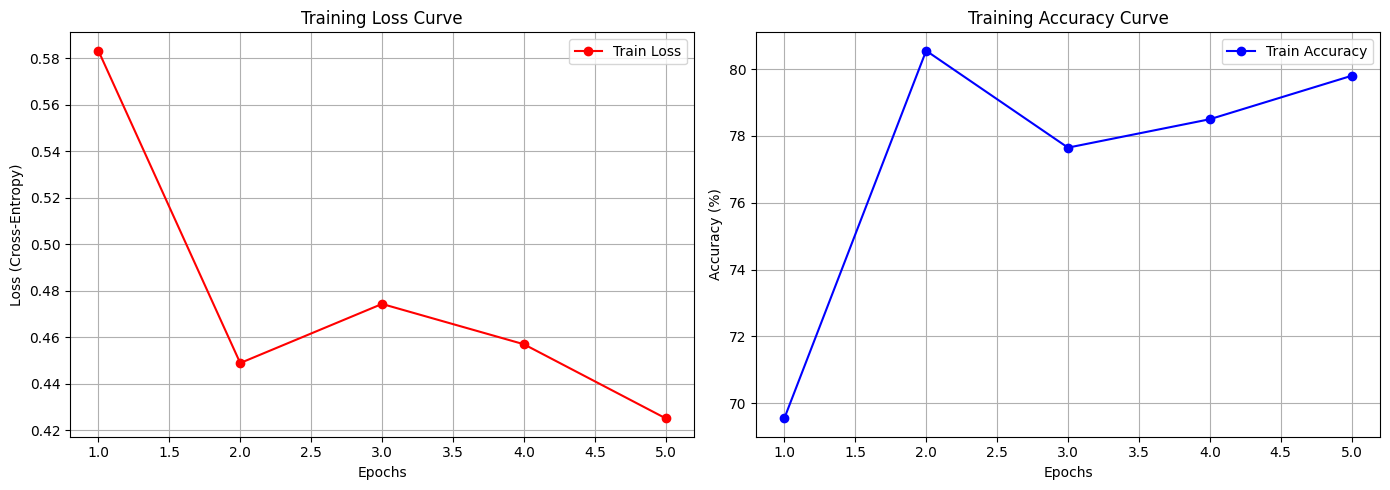

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Curve
axes[0].plot(range(1, epochs + 1), train_losses, marker='o', color='red', label='Train Loss')
axes[0].set_title('Training Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (Cross-Entropy)')
axes[0].grid(True)
axes[0].legend()

# 2. Accuracy Curve
axes[1].plot(range(1, epochs + 1), train_accuracies, marker='o', color='blue', label='Train Accuracy')
axes[1].set_title('Training Accuracy Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

📊 DETAILED DEEP LEARNING CLASSIFICATION METRICS
              precision    recall  f1-score   support

    Airplane       0.72      0.92      0.81       198
  Automobile       0.89      0.65      0.75       202

    accuracy                           0.79       400
   macro avg       0.81      0.79      0.78       400
weighted avg       0.81      0.79      0.78       400



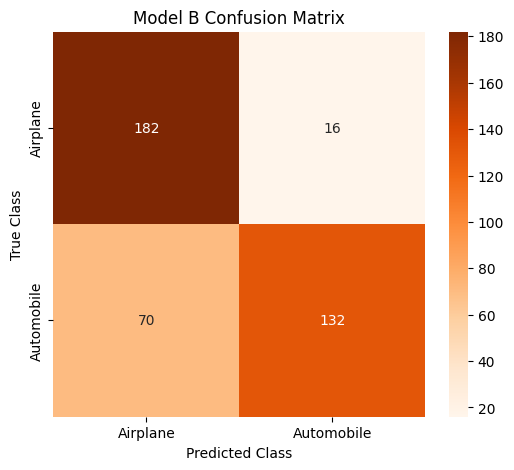

💾 Success! Model weights saved as 'binary_image_classifier.pth'.


In [13]:
model.eval()  # Set model to evaluation mode (stops dropout/batchnorm updates)

all_preds = []
all_labels = []

with torch.no_grad(): # Disable gradient tracking to save memory
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Print metrics
print("📊 DETAILED DEEP LEARNING CLASSIFICATION METRICS")
print("====================================================")
print(classification_report(all_labels, all_preds, target_names=["Airplane", "Automobile"]))

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=["Airplane", "Automobile"], yticklabels=["Airplane", "Automobile"])
plt.title("Model B Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

# 3. Save the trained weights to disk
torch.save(model.state_dict(), 'binary_image_classifier.pth')
print("💾 Success! Model weights saved as 'binary_image_classifier.pth'.")


In [15]:
def predict_local_image(image_path_or_url):
    # 1. Re-initialize a clean ResNet18 structure
    inference_model = resnet18()
    inference_model.fc = nn.Linear(inference_model.fc.in_features, 2)
    
    # 2. Load our saved training state
    inference_model.load_state_dict(torch.load('binary_image_classifier.pth', map_location=device))
    inference_model = inference_model.to(device)
    inference_model.eval()
    
    # 3. Generate a fake test image (represented by a random noise tensor)
    # In practice, you would replace this with an actual image file
    print(f"📷 Simulating inference on custom user image...")
    dummy_image = torch.randn(1, 3, 32, 32).to(device) # Shape: [Batch, Channel, Height, Width]
    
    # 4. Predict
    with torch.no_grad():
        output = inference_model(dummy_image)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)
        
    classes = ["Airplane", "Automobile"]
    predicted_class = classes[predicted_idx.item()]
    confidence_percentage = confidence.item() * 100
    
    print("\n🔮 INFERENCE DECISION RESULT:")
    print("====================================")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence:      {confidence_percentage:.2f}%")

# Execute our inference function
predict_local_image('dummy_path.jpg')


📷 Simulating inference on custom user image...

🔮 INFERENCE DECISION RESULT:
Predicted Class: Airplane
Confidence:      88.43%
